# Day 2 Assignment - In-depth Exploratory Data Analysis on Netflix Dataset
## Name: Divyashree R

### Project Objective

This project performs an in-depth exploratory data analysis (EDA) on the Netflix titles dataset. The goal is to understand patterns and trends in Netflix's content library, including ratings distribution, content type trends, production timelines, and textual characteristics of content descriptions.

The analysis follows a structured approach:

1. Data loading and dataset overview  
2. Data cleaning and preprocessing  
3. Feature preparation for analysis  
4. Exploratory analysis to answer key questions  

The main objective of this assignment is to analyze the dataset and answer the following questions:

- How has the distribution of content ratings changed over time?
- Is there a relationship between content age and its type (Movie vs TV Show)?
- Can we identify trends in content production based on the release year vs the year added to Netflix?
- What are the most common word pairs or phrases in content descriptions?
- Who are the top directors contributing the most content on Netflix?

Google Colab Link: https://colab.research.google.com/drive/1k5wYQz7wMSm_qpknltue48Gk2GGkFl3B?usp=sharing

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
from collections import Counter
import re
from wordcloud import WordCloud
pd.set_option('display.max_columns', None)

In [ ]:
!git clone 'https://github.com/HarshvardhanSingh-13/Datasets'

fatal: destination path 'Datasets' already exists and is not an empty directory.


## Step 1: Loading the Dataset

The Netflix dataset contains information about movies and TV shows available on Netflix including title, director, cast, country, release year, rating, duration, and description.

In [ ]:
df = pd.read_csv('/content/Datasets/Netflix_Titles Dataset/netflix_titles.csv')

In [ ]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


In [ ]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7782,s7783,Movie,Zozo,Josef Fares,"Imad Creidi, Antoinette Turk, Elias Gergi, Car...","Sweden, Czech Republic, United Kingdom, Denmar...","October 19, 2020",2005,TV-MA,99 min,"Dramas, International Movies",When Lebanon's Civil War deprives Zozo of his ...
7783,s7784,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...
7784,s7785,Movie,Zulu Man in Japan,NaN,Nasty C,NaN,"September 25, 2020",2019,TV-MA,44 min,"Documentaries, International Movies, Music & M...","In this documentary, South African rapper Nast..."
7785,s7786,TV Show,Zumbo's Just Desserts,NaN,"Adriano Zumbo, Rachel Khoo",Australia,"October 31, 2020",2019,TV-PG,1 Season,"International TV Shows, Reality TV",Dessert wizard Adriano Zumbo looks for the nex...
7786,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,Sam Dunn,NaN,"United Kingdom, Canada, United States","March 1, 2020",2019,TV-MA,90 min,"Documentaries, Music & Musicals",This documentary delves into the mystique behi...


## Step 2: Understanding the Dataset Structure


In [ ]:
print("Dataset Shape:", df.shape)

print("\nColumns in dataset:\n", df.columns.tolist())

Dataset Shape: (7787, 12)

Columns in dataset:
 ['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       7787 non-null   object
 1   type          7787 non-null   object
 2   title         7787 non-null   object
 3   director      5398 non-null   object
 4   cast          7069 non-null   object
 5   country       7280 non-null   object
 6   date_added    7777 non-null   object
 7   release_year  7787 non-null   int64 
 8   rating        7780 non-null   object
 9   duration      7787 non-null   object
 10  listed_in     7787 non-null   object
 11  description   7787 non-null   object
dtypes: int64(1), object(11)
memory usage: 730.2+ KB


In [ ]:
df.describe()

,release_year
count,7787.000000
mean,2013.932580
std,8.757395
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2018.000000
max,2021.000000


In [ ]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,216,492,7769
top,s7787,Movie,ZZ TOP: THAT LITTLE OL' BAND FROM TEXAS,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,1608,334,3


In [ ]:
# Distribution of Movies vs TV Shows
df['type'].value_counts()

,count
type,
Movie,5377
TV Show,2410


In [ ]:
# Percentage distribution
df['type'].value_counts(normalize=True) * 100

,proportion
type,
Movie,69.050982
TV Show,30.949018


In [ ]:
# Top content ratings
df['rating'].value_counts().head(10)

,count
rating,
TV-MA,2863
TV-14,1931
TV-PG,806
R,665
PG-13,386
TV-Y,280
TV-Y7,271
PG,247
TV-G,194


In [ ]:
# Top producing countries
df['country'].value_counts().head(10)

,count
country,
United States,2555
India,923
United Kingdom,397
Japan,226
South Korea,183
Canada,177
Spain,134
France,115
Egypt,101


## Step 3: Missing Value Analysis

Before any transformation, we must identify and quantify missing values.

This helps us decide whether to:
- Drop rows
- Impute values
- Or create new derived features

In [ ]:
df.isna().sum().sort_values(ascending=False)

,0
director,2389
cast,718
country,507
date_added,10
rating,7
title,0
show_id,0
type,0
release_year,0
duration,0


In [ ]:
missing_values = df.isna().sum()
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': (missing_values / len(df)) * 100})
missing_df.sort_values(by='Missing Values', ascending=False)

,Missing Values,Percentage (%)
director,2389,30.679337
cast,718,9.220496
country,507,6.510851
date_added,10,0.128419
rating,7,0.089893
title,0,0.000000
show_id,0,0.000000
type,0,0.000000
release_year,0,0.000000
duration,0,0.000000


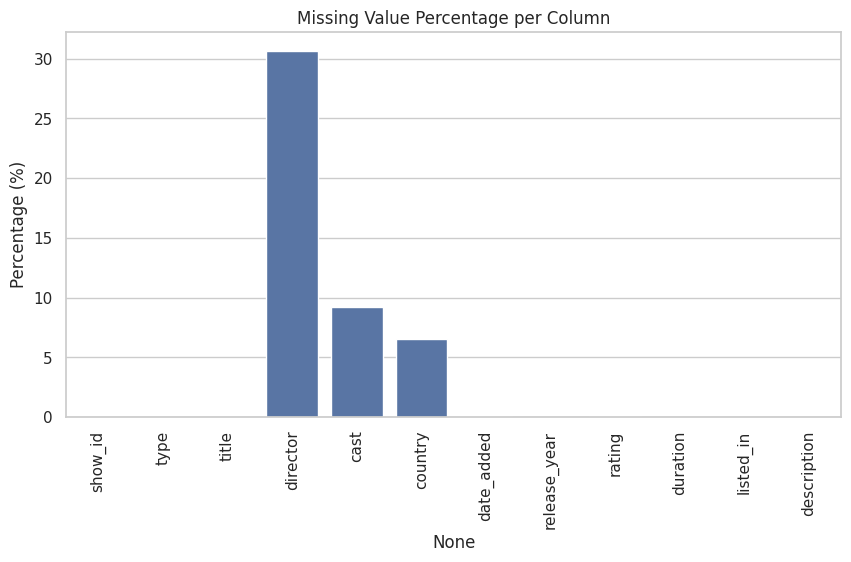

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=missing_df.index, y=missing_df['Percentage (%)'])
plt.xticks(rotation=90)
plt.title("Missing Value Percentage per Column")
plt.show()

## Step 4: Handling Missing Values

In this step, we clean the missing values in a logical way.

- Fill missing **director** with "Unknown"
- Fill missing **cast** with "Not Specified"
- Fill missing **country** with "Unknown"
- Drop rows where **date_added** is missing (very few rows)
- Fill missing **rating** with the most common rating

This ensures the dataset is clean before further analysis.

In [ ]:
df['director'] = df['director'].fillna("Unknown")
df['cast'] = df['cast'].fillna("Not Specified")
df['country'] = df['country'].fillna("Unknown")

In [ ]:
df = df.dropna(subset=['date_added'])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [ ]:
df.isna().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


## Step 5: Converting Date Column

The date_added column is currently stored as text.

We convert it into datetime format so that we can:
- Extract year and month
- Perform time-series analysis
- Study content growth trends

In [ ]:
df['date_added'] = pd.to_datetime(df['date_added'],format='mixed',dayfirst=False)

In [ ]:
# Extract year and month from date_added
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month
df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2020-08-14,2020,8
1,2016-12-23,2016,12
2,2018-12-20,2018,12
3,2017-11-16,2017,11
4,2020-01-01,2020,1


In [ ]:
# Remove extra spaces
df['country'] = df['country'].str.strip()
df['rating'] = df['rating'].str.strip()
# Convert type column to category
df['type'] = df['type'].astype('category')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added
0,s1,TV Show,3%,Unknown,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,2020-08-14,2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...,2020,8
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,2016-12-23,2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...,2016,12
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,2018-12-20,2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow...",2018,12
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,2017-11-16,2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi...",2017,11
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,2020-01-01,2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...,2020,1


## Step 6: Preparing Text Data for Analysis

To analyze common word pairs in descriptions, we first convert text to lowercase and remove unnecessary punctuation.

In [ ]:
df['description_clean'] = df['description'].str.lower()

In [ ]:
df.duplicated().sum()

np.int64(0)

# Submission Questions

After cleaning and preparing the dataset, we now perform deeper analysis to answer the required questions about Netflix content trends.

## Question 1: Distribution of Content Ratings Over Time

Here, we analyze how the distribution of content ratings has changed over time on Netflix.

Content ratings indicate the target audience or maturity level of shows and movies. By examining rating trends across years, we can observe how Netflix's content strategy has evolved and whether the platform has focused more on certain audience categories over time.

In [ ]:
rating_year = df.groupby(['year_added', 'rating']).size().reset_index(name='count')
rating_year.head()

,year_added,rating,count
0,2008,TV-MA,2
1,2009,TV-MA,2
2,2010,NR,1
3,2011,TV-14,5
4,2011,TV-MA,3


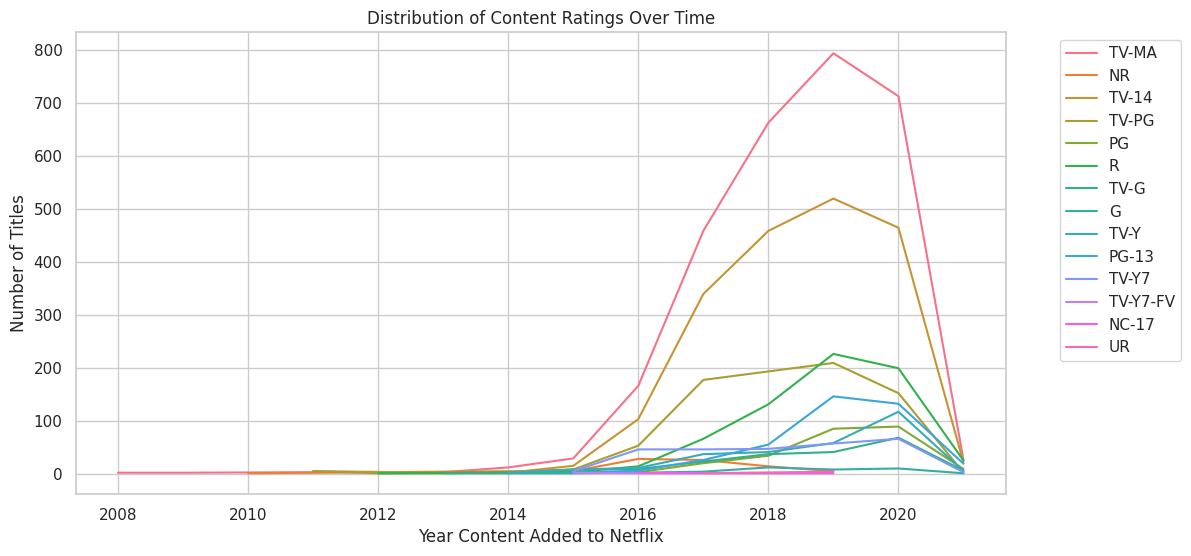

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=rating_year, x='year_added', y='count', hue='rating')
plt.title("Distribution of Content Ratings Over Time")
plt.xlabel("Year Content Added to Netflix")
plt.ylabel("Number of Titles")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

### Interpretation

- The chart shows how different content ratings have evolved on Netflix over time. A clear trend can be observed starting around **2016**, where the number of titles added to the platform increased significantly.
- Among all ratings, **TV-MA dominates the Netflix catalog**, indicating that a large portion of Netflix content is targeted toward mature audiences.
- The **TV-14 rating is the second most common**, suggesting that Netflix also produces a significant amount of content aimed at teenagers and young adults.
- The number of titles across most ratings peaks between **2018 and 2019**, reflecting a period when Netflix rapidly expanded its content library.
- Other ratings such as **PG, TV-PG, TV-Y, and PG-13** appear in smaller quantities, indicating that content for younger audiences represents a smaller portion of the overall catalog.

## Question 2: Relationship Between Content Age and Content Type

Here, we analyze whether there is a relationship between the age of content and its type (Movie or TV Show).

Content age is calculated as the difference between the current year and the release year of the content. By comparing the age distribution for movies and TV shows, we can observe whether older content is more common in one category.

In [ ]:
current_year = 2024
df['content_age'] = current_year - df['release_year']
df[['release_year','content_age']].head()

,release_year,content_age
0,2020,4
1,2016,8
2,2011,13
3,2009,15
4,2008,16


In [ ]:
df.groupby('type', observed=False)['content_age'].mean()

,content_age
type,
Movie,11.079970
TV Show,7.787917


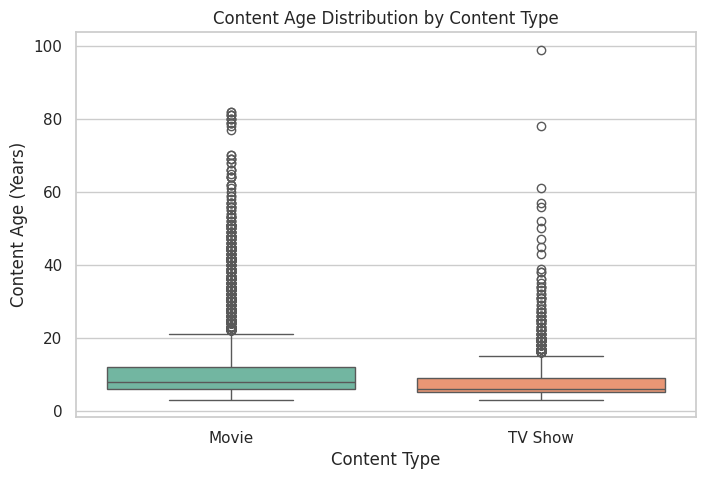

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='type', y='content_age', palette='Set2', hue='type')
plt.title("Content Age Distribution by Content Type")
plt.xlabel("Content Type")
plt.ylabel("Content Age (Years)")
plt.show()

### Interpretation

- The analysis compares the age distribution of movies and TV shows available on Netflix. Content age was calculated as the difference between the current year and the release year.

- From the grouped statistics, movies have an average content age of **approximately 11 years**, while TV shows have a lower average age of **around 7.8 years**. This indicates that movies available on Netflix tend to be older compared to TV shows.

- The boxplot visualization further supports this observation. Movies show a **wider spread of content ages**, suggesting that Netflix includes many older films in its catalog. In contrast, TV shows are generally **more recent**, with a slightly narrower distribution.

- Several **outliers** appear in both categories, representing very old titles that are still available on the platform. Overall, the results suggest that Netflix's movie library contains more legacy content, while TV shows are typically more modern releases.

## Question 3: Trends in Content Production (Release Year vs Year Added)

In this question, we analyze trends in content production by comparing the release year of titles with the year they were added to Netflix.

This helps us understand whether Netflix primarily adds newly released content or includes older content from previous years. By visualizing these trends, we can observe how Netflix’s content acquisition strategy has evolved over time.

In [ ]:
release_trend = df.groupby('release_year').size().reset_index(name='count')
release_trend.head()

,release_year,count
0,1925,1
1,1942,2
2,1943,3
3,1944,3
4,1945,3


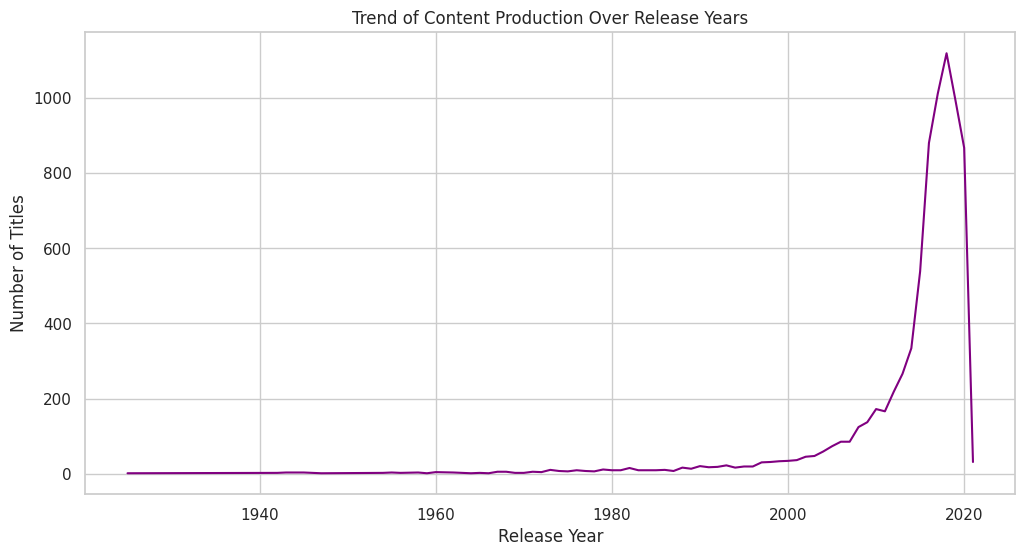

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(data=release_trend, x='release_year', y='count', color='purple')
plt.title("Trend of Content Production Over Release Years")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.show()

### Interpretation

- The chart shows how the number of titles released each year has changed over time. Very few titles appear in the dataset before the year 2000, indicating limited representation of older productions in the Netflix catalog.

- From the early 2000s onward, the number of releases begins to gradually increase. This growth becomes much more noticeable after **2010**, suggesting that Netflix increasingly includes modern content in its library.

- A significant surge in the number of titles occurs between **2015 and 2019**, with the peak appearing around **2019**, where the highest number of titles were released. This period reflects the rapid expansion of Netflix's content library and increased production of original and licensed content.

- After 2020, the number of titles drops sharply. This decline may occur because recently produced content has not yet been fully added to the dataset or because the dataset contains fewer entries for the most recent years.

- Overall, the trend suggests that Netflix's catalog is strongly dominated by **modern content produced in the last decade**, with a major growth phase occurring during the mid-to-late 2010s.

### Word Cloud of Netflix Content Descriptions

A word cloud visualization is used to identify the most frequent words appearing in Netflix content descriptions. Larger words represent higher frequency in the dataset.

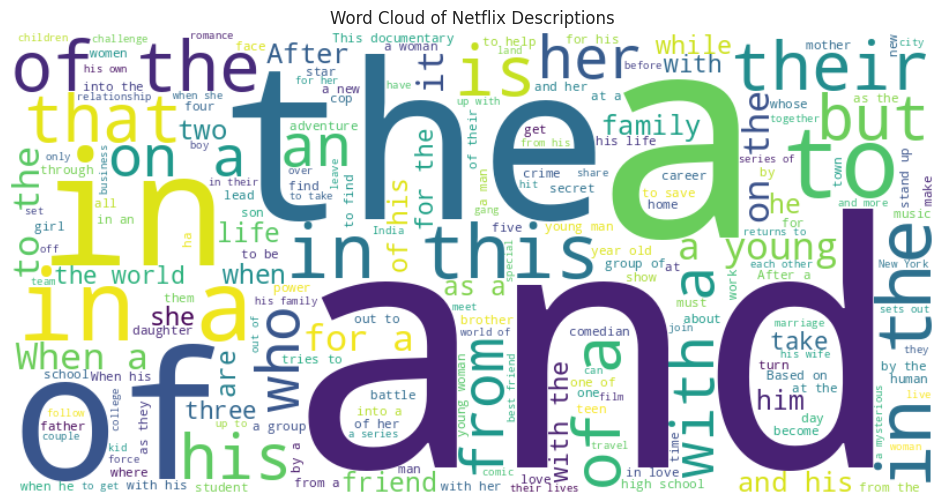

In [ ]:
text = " ".join(df['description'].dropna())
wordcloud = WordCloud(width=800, height=400, background_color='white',stopwords='english').generate(text)
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud of Netflix Descriptions")
plt.show()

## Question 4: Most Common Word Pairs in Content Descriptions

Here, we analyze the text descriptions of Netflix titles to identify the most common word pairs (bigrams).

Bigrams help reveal recurring themes and phrases in the dataset, such as references to relationships, crime stories, family themes, or adventures. Extracting these patterns provides insights into the types of narratives commonly present in Netflix content.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(stop_words='english', ngram_range=(2,2))

X = vectorizer.fit_transform(df['description'])

bigram_counts = X.sum(axis=0)
bigram_freq = [(word, bigram_counts[0, idx])
    for word, idx in vectorizer.vocabulary_.items()]
bigram_freq = sorted(bigram_freq, key=lambda x: x[1], reverse=True)
bigram_freq[:10]

[('high school', np.int64(133)),
 ('year old', np.int64(130)),
 ('young man', np.int64(103)),
 ('young woman', np.int64(98)),
 ('new york', np.int64(86)),
 ('small town', np.int64(59)),
 ('best friend', np.int64(51)),
 ('true story', np.int64(48)),
 ('world war', np.int64(47)),
 ('stand special', np.int64(47))]

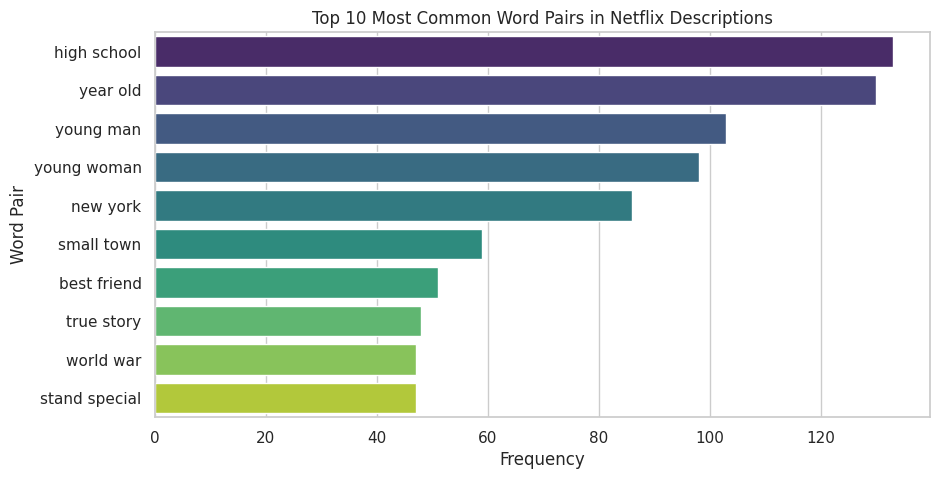

In [ ]:
top_bigrams = bigram_freq[:10]
words = [x[0] for x in top_bigrams]
counts = [x[1] for x in top_bigrams]
plt.figure(figsize=(10,5))
sns.barplot(x=counts, y=words, hue=words, palette="viridis", legend=False)
plt.title("Top 10 Most Common Word Pairs in Netflix Descriptions")
plt.xlabel("Frequency")
plt.ylabel("Word Pair")
plt.show()

### Interpretation

- The bigram analysis reveals the most frequently occurring word pairs in Netflix content descriptions. The results highlight several recurring themes and narrative patterns within the dataset.

- Phrases such as **"high school"** and **"year old"** appear most frequently, indicating that many Netflix titles revolve around teenage or coming-of-age stories. Similarly, phrases like **"young man"** and **"young woman"** suggest that character-driven narratives focusing on young protagonists are common.

- Location-based phrases such as **"New York"** and **"small town"** indicate that many stories are set in recognizable urban or small-town environments. Relationship-oriented phrases like **"best friend"** further emphasize the importance of personal relationships in storytelling.

- Also, terms such as **"true story"** and **"world war"** suggest the presence of historical and biographical content, while **"stand special"** likely refers to stand-up comedy specials available on Netflix.

- Overall, the bigram analysis shows that Netflix content frequently focuses on **youth, relationships, familiar locations, and real-life inspired stories**, reflecting common narrative themes in entertainment media.

## Question 5: Top Directors on Netflix

In this question, we identify the directors who have contributed the most titles to Netflix.

By analyzing the frequency of directors in the dataset, we can determine which filmmakers have the largest presence on the platform. This provides insight into recurring collaborations and popular directors within Netflix’s catalog.

In [ ]:
# Remove missing director values
director_df = df.dropna(subset=['director'])
# Count titles by director
top_directors = director_df['director'].value_counts().head(10)
top_directors

,count
director,
Unknown,2379
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Youssef Chahine,12
Jay Chapman,12
Steven Spielberg,10


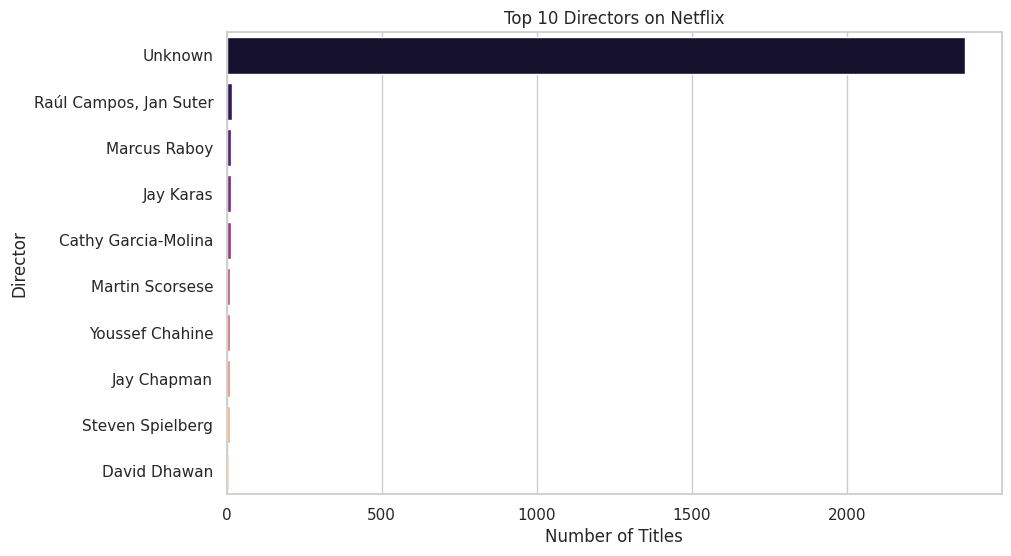

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index,hue=top_directors.index, palette="magma", legend=False)
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

### Interpretation

- The analysis identifies the directors who have contributed the highest number of titles to the Netflix dataset. The results show that **"Unknown" appears as the most frequent category**, with a significantly larger number of titles compared to individual directors.

- This occurs because many entries in the dataset do not contain information about the director, resulting in missing values that are categorized as "Unknown". As a result, the chart highlights a limitation of the dataset, where director information is incomplete for a large portion of titles.

- Excluding the unknown entries, several directors appear multiple times in the dataset. **Raúl Campos & Jan Suter** lead among identified directors, followed by **Marcus Raboy** and **Jay Karas**. Many of these directors are known for directing stand-up comedy specials and Netflix-produced shows, which explains their repeated appearance.

In [ ]:
# Remove 'Unknown' if it exists
director_df = director_df[director_df['director'] != 'Unknown']
top_directors = director_df['director'].value_counts().head(10)
top_directors

,count
director,
"Raúl Campos, Jan Suter",18
Marcus Raboy,16
Jay Karas,14
Cathy Garcia-Molina,13
Martin Scorsese,12
Jay Chapman,12
Youssef Chahine,12
Steven Spielberg,10
David Dhawan,9


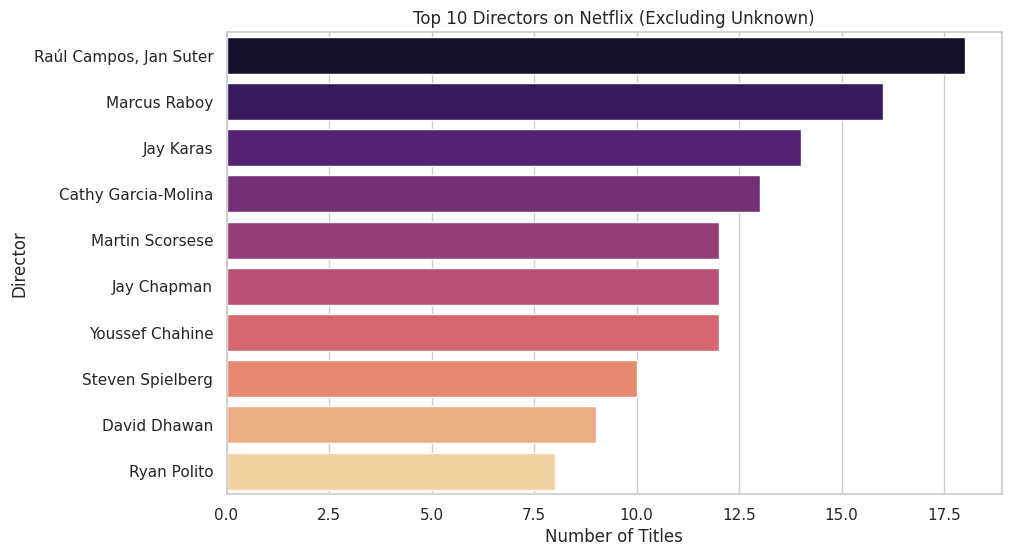

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(x=top_directors.values, y=top_directors.index,hue=top_directors.index, palette="magma", legend=False)
plt.title("Top 10 Directors on Netflix (Excluding Unknown)")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.show()

### Interpretation

- After removing missing and unknown entries, the analysis highlights the directors who have contributed the highest number of titles to Netflix.

- The results show that **Raúl Campos and Jan Suter** appear as the most frequent directors in the dataset, followed by **Marcus Raboy** and **Jay Karas**. Many of these directors are known for directing stand-up comedy specials and Netflix productions, which explains their repeated appearance.

- Other notable directors include **Cathy Garcia-Molina**, **Martin Scorsese**, **Youssef Chahine**, and **Steven Spielberg**, indicating that both international and well-known filmmakers are represented on the platform.

### Conclusion

In this project, we performed an in-depth Exploratory Data Analysis (EDA) on the Netflix dataset to understand patterns in content distribution, production trends, and textual descriptions.

- From the analysis, we observed that the number of titles added to Netflix increased significantly after 2015, indicating rapid expansion of the platform's content library. Content ratings such as **TV-MA** and **TV-14** appeared most frequently, suggesting that Netflix hosts a large amount of mature and teen-oriented content.

- The analysis of **content age** showed that movies tend to be slightly older on average compared to TV shows, indicating that Netflix often acquires older films while continuously adding newer TV series.

- When examining **production trends**, the number of titles released increased sharply in recent years, reflecting the growth of global entertainment production and Netflix’s strategy of expanding its catalog.

- Text analysis of content descriptions revealed common themes such as **coming-of-age stories, relationships, urban settings, and real-life inspired narratives**, highlighted through frequent word pairs like **high school**, **young man**, and **true story**.

- Finally, the director analysis showed that certain directors appear multiple times in the dataset, indicating recurring collaborations and specialization in specific content types such as comedy specials.

Overall, this EDA provides valuable insights into Netflix's content strategy, popular storytelling themes, and evolving production trends.
